In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches, lines
import matplotlib as mpl

In [3]:
img = plt.imread("IMG_5232.jpeg")
h, w, _ = img.shape

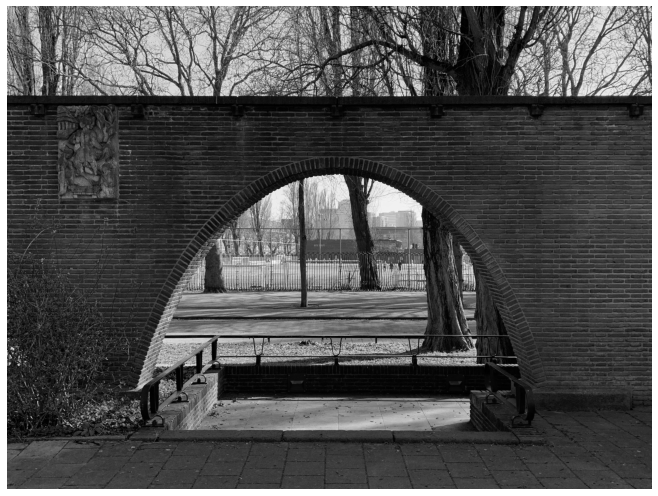

In [4]:
fig, ax = plt.subplots(figsize = (10, 7))
ax.imshow(np.mean(img, axis = -1), cmap = 'gray')
ax.axis('off')
ax.set_ylim([3000, 800])

fig.tight_layout()
fig.savefig("arch.png", dpi = 150)

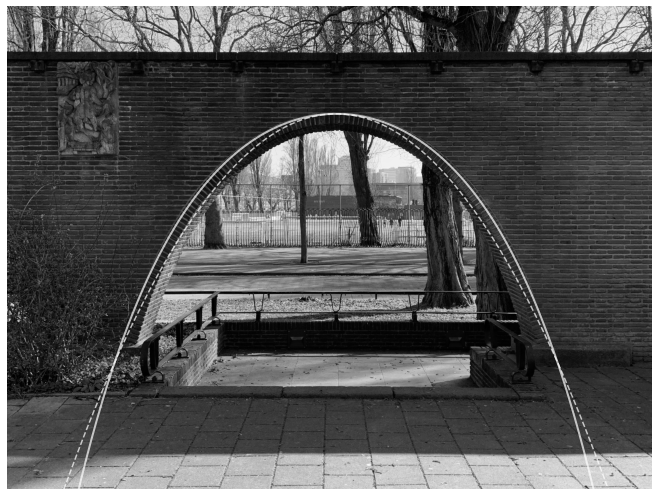

In [5]:
fig, ax = plt.subplots(figsize = (10, 7))

o = [1500, 1490]

ax.imshow(np.mean(img, axis = -1), cmap = 'gray')

x = np.linspace(0*w/2, w, 1000)
ax.plot(x, ((x-o[0])/30)**2 + o[1], c = [1, 1, 1, 0.7], ls = "--")
ax.plot(x, 400*(np.cosh((x-o[0])/500) - 1) + o[1], c = [1, 1, 1, 0.7], lw = 2)
# ax.plot(x, 400*(np.cosh((x-o[0])/400) - 1) + o[1])

r = patches.Rectangle((w/2, h), w, -h, fc = [1, 1, 1, 0.4])
# ax.add_artist(r)

ax.set_xlim([0, w])
ax.set_ylim([3200, 1000])

ax.axis('off')
fig.tight_layout()
fig.savefig("arch-construction.png", dpi = 150)

(0.0, 1.0)

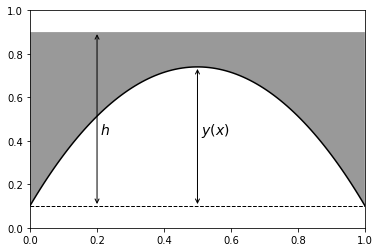

In [6]:
fig, ax = plt.subplots()

h_offset = 0.1
x = np.linspace(0, 1, 100)
y = 5*(-np.cosh(x-0.5) + 1.128) + h_offset
x = np.concatenate((x, [1.0, 0.0]))
y = np.concatenate((y, [0.9, 0.9]))
pts = list(zip(x, y))
path = patches.Path(pts)

pat = patches.PathPatch(path, fc = "none", lw = 0)
sq = patches.Rectangle((0, 0.1), 1, 0.8, fc = 3*[0.6])

ax.add_patch(pat)
sqim = ax.add_patch(sq)
sqim.set_clip_path(pat)
ax.plot(x[:-2], y[:-2], c = "k", ls = "-")
ax.hlines([h_offset], 0, 1, color = "k", ls = "--", lw = 1)
ax.annotate("", (0.2, h_offset), (0.2, 0.9),
            arrowprops=dict(arrowstyle = "<->", fc = "none", ec = "k"))
ax.annotate(r"$h$", (0.21, 0.43), fontsize = 14)
ax.annotate("", (0.5, h_offset), (0.5, 0.74),
            arrowprops=dict(arrowstyle = "<->", fc = "none", ec = "k"))
ax.annotate(r"$y(x)$", (0.51, 0.43), fontsize = 14)
ax.set_ylim([0, 1])
ax.set_xlim([0, 1])


In [361]:
meanimg.shape

(3919, 2939)

In [364]:
from scipy.interpolate import interp1d

In [377]:
meanimg = np.mean(img, axis = -1)

old_x = np.arange(meanimg.shape[0])
stretch_factor = 1.15
new_x = np.arange(int(stretch_factor * meanimg.shape[0]))
interpimg = interp1d(old_x, meanimg, axis = 0)(new_x/stretch_factor)


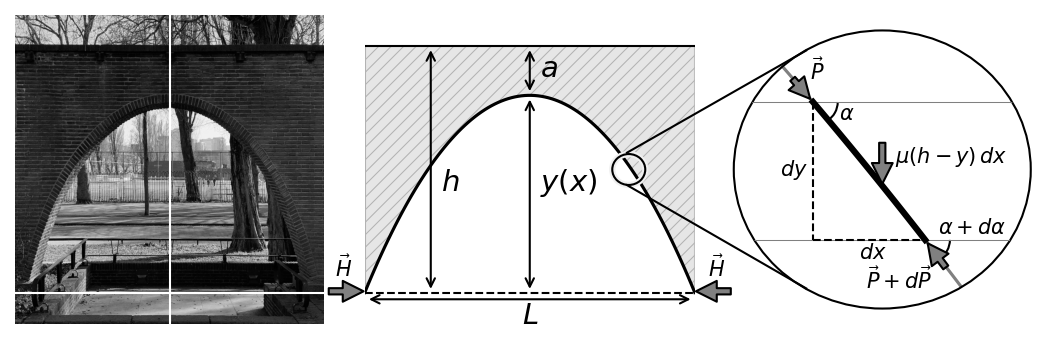

In [697]:
figscale = 0.8
fig, ax = plt.subplots(1, 3, figsize = (9*figscale, 3*figscale))


ax[0].imshow(interpimg[1200:3200, 500:2500], cmap = 'gray')
h_offset_photo = 1800
ax[0].hlines([1800], 0, 2000, color = "w", lw = 1)
ax[0].vlines([1000], -0.5, 1999.5, color = "w", lw = 1)
ax[0].axis('off')

h_offset = 0.1
x = np.linspace(0, 1, 100)
y = 5*(-np.cosh(x-0.5) + 1.128) + h_offset
x = np.concatenate((x, [1.0, 0.0]))
y = np.concatenate((y, [0.9, 0.9]))
pts = list(zip(x, y))
path = patches.Path(pts)

pat = patches.PathPatch(path, fc = "none", lw = 0)
mpl.rcParams['hatch.linewidth'] = 0.5
sq = patches.Rectangle((0, 0.1), 1, 0.8, fc = 3*[0.9], hatch = "////", ec = 3*[0.7])

ax[1].add_patch(pat)
sqim = ax[1].add_patch(sq)
sqim.set_clip_path(pat)
ax[1].plot(x[:-2], y[:-2], c = "k", ls = "-")
ax[1].hlines([h_offset], 0, 1, color = "k", ls = "--", lw = 1)
ax[1].hlines([h_offset + 0.8], 0, 1, color = "k", ls = "-", lw = 1)

ax[1].annotate("", (0.2, h_offset), (0.2, 0.9),
            arrowprops=dict(arrowstyle = "<->", fc = "none", ec = "k"))
ax[1].annotate(r"$h$", (0.23, 0.43), fontsize = 14)
ax[1].annotate("", (0.5, h_offset), (0.5, 0.74),
            arrowprops=dict(arrowstyle = "<->", fc = "none", ec = "k"))
ax[1].annotate(r"$y(x)$", (0.53, 0.43), fontsize = 14)
ax[1].annotate("", (0.5, 0.74), (0.5, 0.9),
            arrowprops=dict(arrowstyle = "<->", fc = "none", ec = "k"))
ax[1].annotate(r"$a$", (0.53, 0.8), fontsize = 14, c = "k")
ax[1].annotate("", (0, 0.08), (1, 0.08),
              arrowprops=dict(arrowstyle = "<->", fc = "none", ec = "k"))
ax[1].annotate(r"$L$", (0.5, -0.00), fontsize = 14,
               horizontalalignment = "center")
ax[1].set_ylim([0, 1])
ax[1].set_xlim([0, 1])
ax[1].axis('off')

circ1 = patches.Circle((0.8, 0.5), 0.05, ec = "k", fc = "none", zorder = 10)
circ0 = patches.Circle((0.8, 0.5), 0.05, ec = "#f0f0f0", fc = "none", lw = 3, zorder = 10)
ax[1].add_patch(circ0)
ax[1].add_patch(circ1)

dx = 0.07
circ2 = patches.Circle((0.5 + dx, 0.5), 0.45, ec = "k", fc = "none")
ax[2].add_patch(circ2)
ax[2].axis('off')

ll = lines.Line2D([0.59, 0.756], [0.555, 0.839], lw = 1, c = "k")
ll2 = lines.Line2D([0.59, 0.756], [0.465, 0.178], lw = 1, c = "k")

x0 = 0.36
x1 = 0.7
xd2 = np.linspace(x0, x1, 100)
xd3 = np.linspace(0.0, 1, 100)
yd2 = (-np.cosh((0.2*xd2+0.98)) + 1.75) * 5
y0 = np.max(yd2)
y1 = np.min(yd2)
yd3 = (-np.cosh((0.2*xd3+0.98)) + 1.75) * 5

ax[2].plot(xd2, yd2, lw = 3, c = "k")
ax[2].plot(xd3, yd3, clip_path = circ2, c = "gray", zorder = -5)
ax[2].plot([x0, x0], [y0, y1], c = "k", ls = "--", lw = 1)
ax[2].plot([x0, x1], [y1, y1], c = "k", ls = "--", lw = 1)
ax[2].hlines([y0, y1], 0, 1, clip_path = circ2, color = "gray", lw = 0.5)

arc1 = patches.Arc([x0, y0], 0.15, 0.15,
                   angle = 0,
                   theta1 = -55,
                   theta2 = 0)
arc2 = patches.Arc([x1, y1], 0.15, 0.15,
                   angle = 0,
                   theta1 = -55,
                   theta2 = 0)
ax[2].add_patch(arc1)
ax[2].add_patch(arc2)
ax[2].annotate(r"$dx$", (0.5, 0.21))
ax[2].annotate(r"$dy$", (0.26, 0.48))
ax[2].annotate(r"$\alpha$", (0.44, 0.66))
ax[2].annotate(r"$\alpha + d\alpha$", (0.74, 0.29))

arstyle = "simple,head_width=10,head_length=10,tail_width=3"
ar1 = patches.FancyArrowPatch((x0-0.07, y0+0.085), (x0, y0), fc = "gray",
                             arrowstyle = arstyle)
ar2 = patches.FancyArrowPatch((x1+0.07, y1-0.1), (x1, y1), fc = "gray",
                             arrowstyle = arstyle)
ar3 = patches.FancyArrowPatch((0.57, 0.6), (0.57, 0.44), fc = "gray",
                             arrowstyle = arstyle, zorder = 10)
ax[2].add_patch(ar1)
ax[2].add_patch(ar2)
ax[2].add_patch(ar3)
ax[2].annotate(r"$\vec{P}$", (x0-0.01, y0+0.07))
ax[2].annotate(r"$\vec{P} + d\vec{P}$", (x1-0.18, y1-0.16))
ax[2].annotate(r"$\mu (h - y) \, dx$", (0.78, 0.52), horizontalalignment = "center")

fig.add_artist(ll)
fig.add_artist(ll2)

ar4 = patches.FancyArrowPatch((0.69, 0.17), (0.65, 0.17), fc = "gray",
                             arrowstyle = arstyle, zorder = 10)
ar5 = patches.FancyArrowPatch((0.31, 0.17), (0.35, 0.17), fc = "gray",
                             arrowstyle = arstyle, zorder = 10)
fig.add_artist(ar4)
fig.add_artist(ar5)
fig.text(0.32, 0.21, r"$\vec{H}$")
fig.text(0.665, 0.21, r"$\vec{H}$")

ax[2].set_xlim([dx, 1 + dx])
ax[2].set_ylim([0, 1.0])

fig.set_dpi(150)
fig.tight_layout()
fig.savefig("force-diagram.svg")

In [642]:
a*np.arccosh(h/a)

1.4444059482268925

(0.0, 5.0)

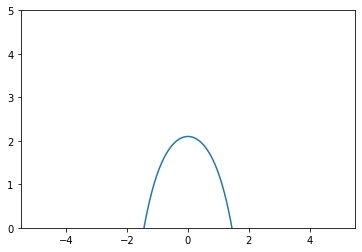

In [639]:
xd = np.linspace(-5, 5, 500)
L = 4.2
h = 2.8
a = 0.7
beta = 2/L * np.arccosh(h/a)
# cat = -a * np.cosh(xd * beta) + h
cat = -a * np.cosh(xd / a) + h

plt.plot(xd, cat)
plt.ylim([0, 5])
# plt.plot(xd, wcat)

In [584]:
np.min(a * np.cosh(xdd * beta / 200) - h)

-2.0923882510246283

In [580]:
a

0.7

In [577]:
h * yscale + yshift

1002.8

In [595]:
a-h

-2.0999999999999996

In [596]:
h

2.8

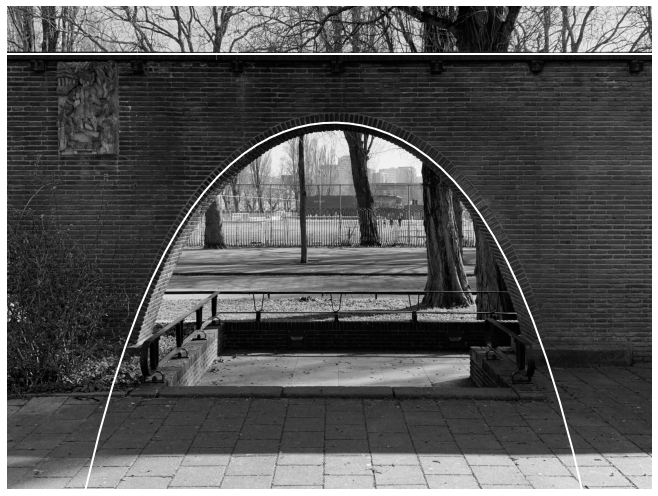

In [638]:
fig, ax = plt.subplots(figsize = (10, 7))

o = [1500, 1490]

ax.imshow(np.mean(img, axis = -1), cmap = 'gray')

xd = np.linspace(0, 2000)
xdd = np.linspace(0, w) - w/2
cat = a * np.cosh((xdd - 20) * beta / 440) - h

yscale = 450
yshift = 2475
plt.plot(xdd + w/2, cat * yscale + yshift, lw = 2, color = "white")
plt.hlines([-h * yscale + yshift], 0, w, lw = 2, color = "white")


ax.set_xlim([0, w])
ax.set_ylim([3200, 1000])
# ax.set_ylim([4000, 0])

ax.axis('off')
fig.tight_layout()
fig.savefig("arch-construction-2.png", dpi = 150)

In [536]:
14*30

420